> Stationary 10-armed bandit

In [109]:
import numpy as np
rng = np.random.default_rng(0)

In [110]:
class Bandit:
    def __init__(self, k=None, **kwargs):
        self.k = k
        self.q = rng.normal(0.0, 1.0, self.k)
        self.optimal_action = self.q.argmax()
        self.r_mu = self.q
        self.r_sigma = 1.0
    
    def step(self, k):
        return rng.normal(self.r_mu[k], self.r_sigma)

In [111]:
from dataclasses import dataclass

@dataclass
class Config:
    bandit_cls: Bandit
    k: int
    time_steps: int
    experiments: int
    eps: float
    constant_step: bool
    alpha: float = None
    noise_var: float = None

In [112]:
class MetricsSingle:
    def __init__(self):
        self.rewards = []
        self.chose_optimal_action = []

    def step(self, reward: float, chose_optimal_action: bool):
        self.rewards.append(reward)
        self.chose_optimal_action.append(chose_optimal_action)

class MetricsCollection:
    def __init__(self, c: Config):
        self.rewards_all = np.zeros((c.experiments, c.time_steps))
        self.chose_optimal_action_all = np.zeros((c.experiments, c.time_steps))
        self.experiments_done = -1

    def save_experiment(self, ms: MetricsSingle):
        self.experiments_done += 1
        self.rewards_all[self.experiments_done] = np.array(ms.rewards)
        self.chose_optimal_action_all[self.experiments_done] = np.array(ms.chose_optimal_action)

    def reward_distribution_over_time(self):
        return np.mean(self.rewards_all, axis=0), np.std(self.rewards_all, axis=0)
    
    def optimal_action_choice_ratio_over_time(self):
        return np.mean(self.chose_optimal_action_all, axis=0)

In [113]:
def do_experiment(c: Config):
    b = c.bandit_cls(k=c.k, noise_var=c.noise_var)
    Q = np.zeros(c.k)
    N = np.zeros(c.k)

    def select_action():
        if c.eps > rng.random():
            return rng.integers(0, c.k)
        return Q.argmax()

    ms = MetricsSingle()
    step_size = (lambda: c.alpha) if c.constant_step else (lambda: 1 / N[A])
    for t in range(c.time_steps):
        A = select_action()
        R = b.step(A)
        N[A] += 1
        Q[A] = Q[A] + step_size() * (R - Q[A])
        ms.step(R, A == b.optimal_action)

    return ms

In [114]:
import matplotlib.pyplot as plt

def plot_rewards(metrics_list: list[MetricsCollection], config_list: list[Config]):
    for m, c in zip(metrics_list, config_list):
        mean_rewards, std_rewards = m.reward_distribution_over_time()
        x = np.arange(len(mean_rewards))
        plt.plot(x, mean_rewards, label=rf'$\epsilon = {c.eps}$')
        plt.fill_between(x, mean_rewards - std_rewards, mean_rewards + std_rewards, alpha=0.2)
    plt.xlabel("t")
    plt.ylabel("Average Reward")
    plt.legend()
    plt.show()

def plot_optimal_action_ratio(metrics_list: list[MetricsCollection], config_list: list[Config]):
    for m, c in zip(metrics_list, config_list):
        y = m.optimal_action_choice_ratio_over_time()
        x = np.arange(len(y))
        plt.plot(x, y, label=rf'$\epsilon = {c.eps}$')
    plt.ylim(0.0, 1.0)
    plt.xlabel("t")
    plt.ylabel("Optimal action ratio")
    plt.legend()
    plt.show()

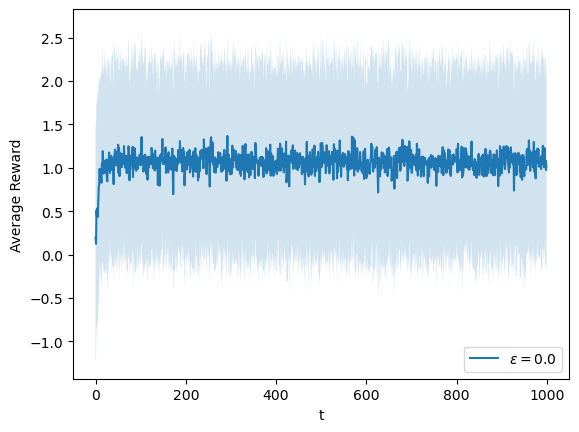

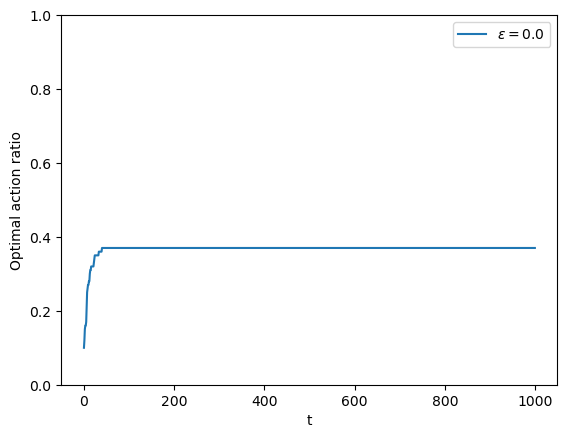

In [115]:
c = Config(
    bandit_cls = Bandit,
    k = 10,
    time_steps = 1000,
    experiments = 100,
    eps = 0.0,
    constant_step = False
)
mc = MetricsCollection(c)

for exp_nr in range(c.experiments):
    ms: MetricsSingle = do_experiment(c)
    mc.save_experiment(ms)

plot_rewards([mc], [c])
plot_optimal_action_ratio([mc], [c])

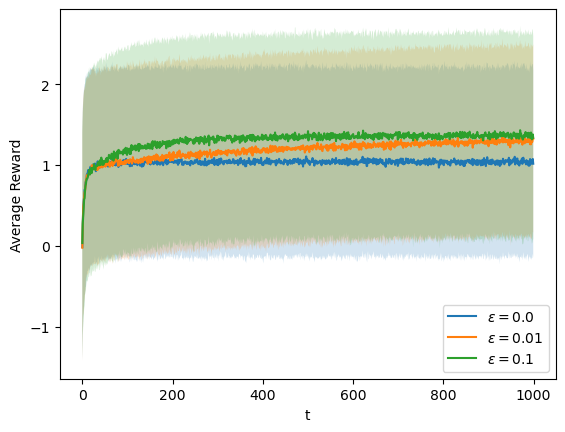

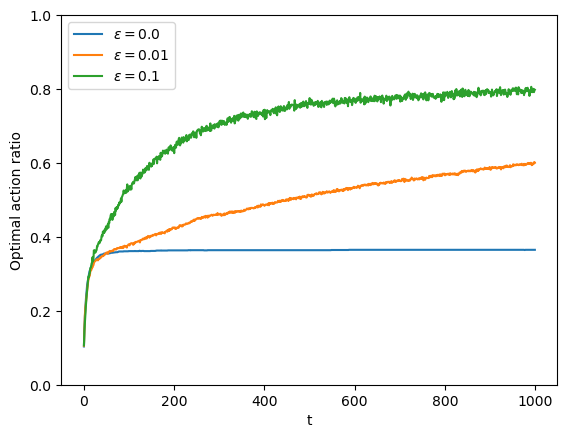

In [116]:
import copy
c1 = Config(
    bandit_cls = Bandit,
    k = 10,
    time_steps = 1000,
    experiments = 2000,
    eps = 0.0,
    constant_step = False
)
c2 = copy.deepcopy(c1)
c2.eps = 0.01
c3 = copy.deepcopy(c1)
c3.eps = 0.1
configs = (c1, c2, c3)

metrics = []
for c in configs:
    mc = MetricsCollection(c)
    for exp_nr in range(c.experiments):
        ms: MetricsSingle = do_experiment(c)
        mc.save_experiment(ms)
    metrics.append(mc)

plot_rewards(metrics, configs)
plot_optimal_action_ratio(metrics, configs)

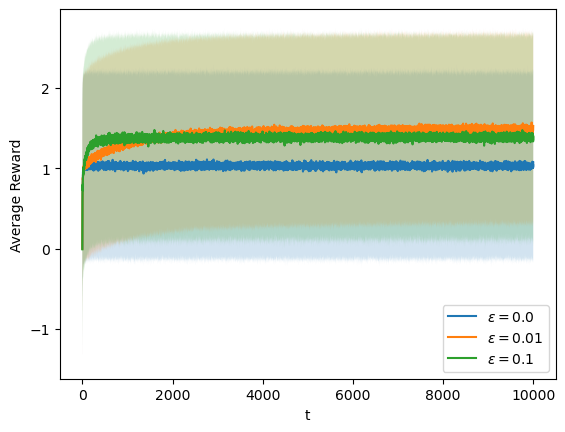

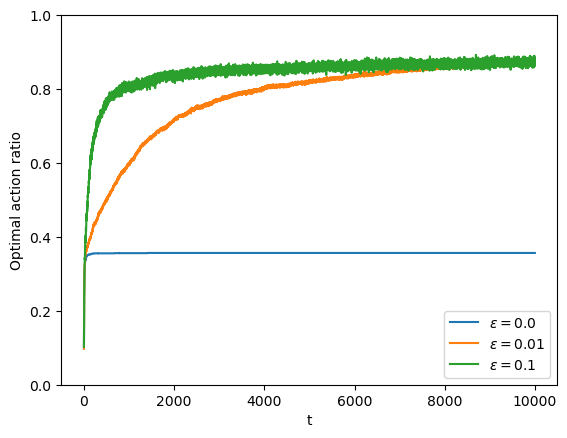

In [117]:
import copy
c1 = Config(
    bandit_cls = Bandit,
    k = 10,
    time_steps = 10000,
    experiments = 2000,
    eps = 0.0,
    constant_step = False,
)
c2 = copy.deepcopy(c1)
c2.eps = 0.01
c3 = copy.deepcopy(c1)
c3.eps = 0.1
configs = (c1, c2, c3)

metrics = []
for c in configs:
    mc = MetricsCollection(c)
    for exp_nr in range(c.experiments):
        ms: MetricsSingle = do_experiment(c)
        mc.save_experiment(ms)
    metrics.append(mc)

plot_rewards(metrics, configs)
plot_optimal_action_ratio(metrics, configs)

> Nonstationary bandit

In [118]:
import numpy as np
rng = np.random.default_rng(0)

In [119]:
class BanditNonstat:
    def __init__(self, k, noise_var, **kwargs):
        self.k = k
        self.noise_var = noise_var
        self.q = np.zeros(k)
        self.optimal_action = self.q.argmax()
        self.r_sigma = 1.0
    
    def _add_noise(self):
        self.q += rng.normal(0, self.noise_var)

    def step(self, k):
        self._add_noise()
        return rng.normal(self.q[k], self.r_sigma)

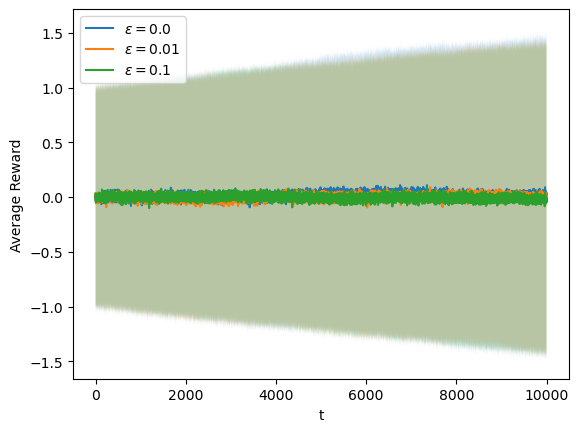

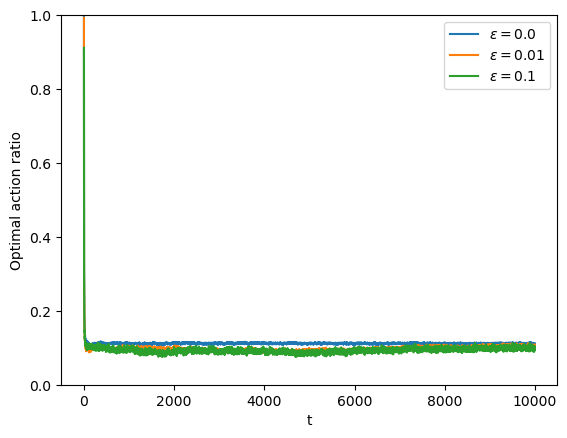

In [120]:
c1 = Config(
    bandit_cls = BanditNonstat,
    k = 10,
    time_steps = 10000,
    experiments = 2000,
    eps = 0.0,
    constant_step = False,
    noise_var = 0.01,
)
c2 = copy.deepcopy(c1)
c2.eps = 0.01
c3 = copy.deepcopy(c1)
c3.eps = 0.1
configs = (c1, c2, c3)

metrics = []
for c in configs:
    mc = MetricsCollection(c)
    for exp_nr in range(c.experiments):
        ms: MetricsSingle = do_experiment(c)
        mc.save_experiment(ms)
    metrics.append(mc)

plot_rewards(metrics, configs)
plot_optimal_action_ratio(metrics, configs)

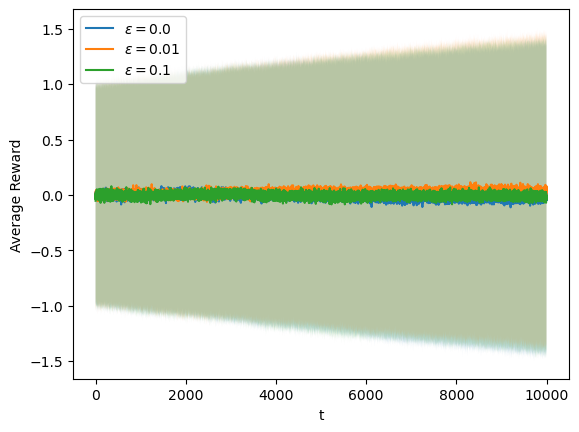

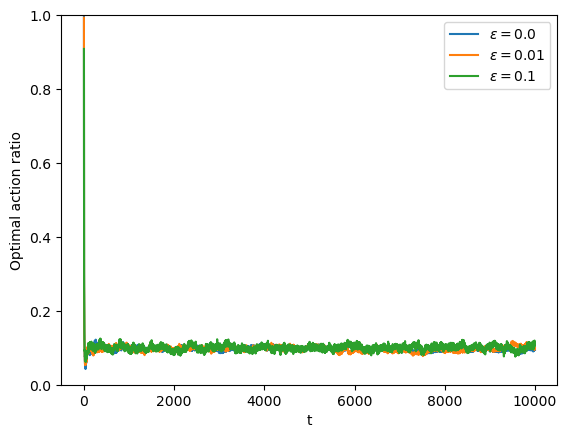

In [121]:
c1 = Config(
    bandit_cls = BanditNonstat,
    k = 10,
    time_steps = 10000,
    experiments = 2000,
    eps = 0.0,
    constant_step = True,
    alpha = 0.1,
    noise_var = 0.01,
)
c2 = copy.deepcopy(c1)
c2.eps = 0.01
c3 = copy.deepcopy(c1)
c3.eps = 0.1
configs = (c1, c2, c3)

metrics = []
for c in configs:
    mc = MetricsCollection(c)
    for exp_nr in range(c.experiments):
        ms: MetricsSingle = do_experiment(c)
        mc.save_experiment(ms)
    metrics.append(mc)

plot_rewards(metrics, configs)
plot_optimal_action_ratio(metrics, configs)

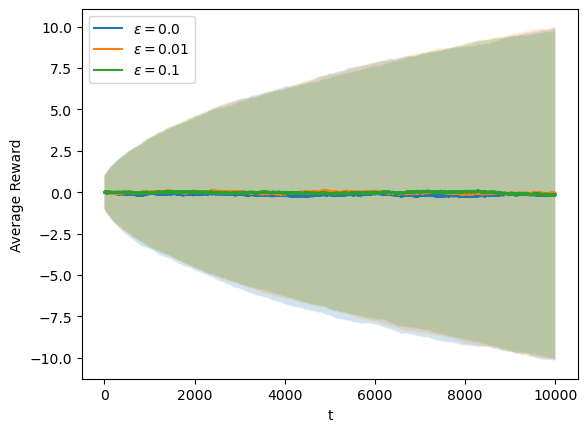

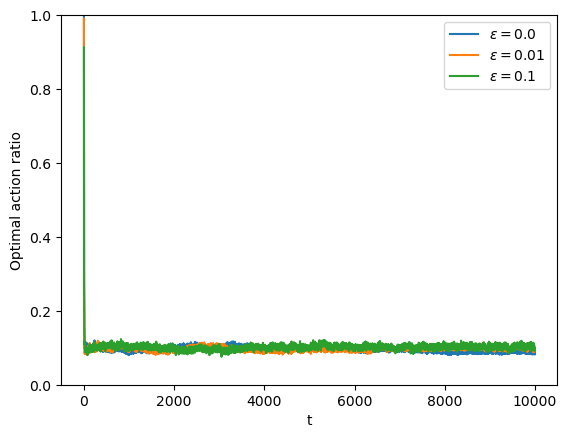

In [122]:
c1 = Config(
    bandit_cls = BanditNonstat,
    k = 10,
    time_steps = 10000,
    experiments = 2000,
    eps = 0.0,
    constant_step = True,
    alpha = 0.1,
    noise_var = 0.1,
)
c2 = copy.deepcopy(c1)
c2.eps = 0.01
c3 = copy.deepcopy(c1)
c3.eps = 0.1
configs = (c1, c2, c3)

metrics = []
for c in configs:
    mc = MetricsCollection(c)
    for exp_nr in range(c.experiments):
        ms: MetricsSingle = do_experiment(c)
        mc.save_experiment(ms)
    metrics.append(mc)

plot_rewards(metrics, configs)
plot_optimal_action_ratio(metrics, configs)

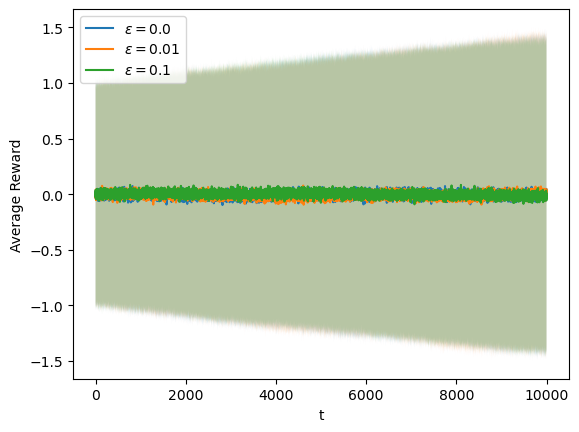

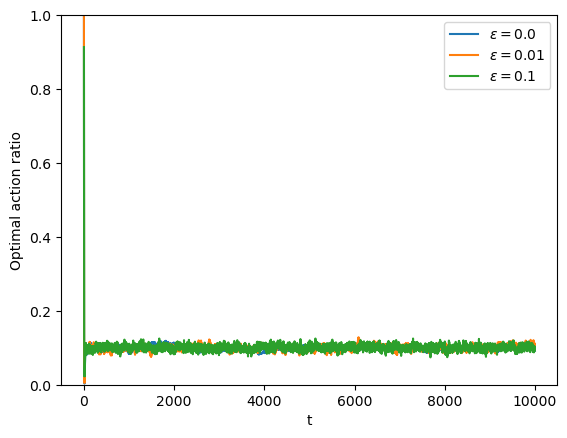

In [123]:
c1 = Config(
    bandit_cls = BanditNonstat,
    k = 10,
    time_steps = 10000,
    experiments = 2000,
    eps = 0.0,
    constant_step = True,
    alpha = 0.75,
    noise_var = 0.01,
)
c2 = copy.deepcopy(c1)
c2.eps = 0.01
c3 = copy.deepcopy(c1)
c3.eps = 0.1
configs = (c1, c2, c3)

metrics = []
for c in configs:
    mc = MetricsCollection(c)
    for exp_nr in range(c.experiments):
        ms: MetricsSingle = do_experiment(c)
        mc.save_experiment(ms)
    metrics.append(mc)

plot_rewards(metrics, configs)
plot_optimal_action_ratio(metrics, configs)